# Covariance Matrix Reconstruction for DOA Estimation
This notebook demonstrates the use of four covariance matrix reconstruction algorithms for Direction of Arrival (DOA) estimation using sparse arrays.

In [1]:
import numpy as np
import doatools.model as model
import doatools.estimation as estimation
import doatools.plotting as doaplt
import matplotlib.pyplot as plt
from doatools.plotting import plot_array
%matplotlib inline

In [2]:
np.random.seed(113)
wavelength = 1.0 # normalized
d0 = wavelength / 2

power_source = 1.0 # Sources share the same power.
power_noise = 10.0 # SNR = 0 dB
n_snapshots = 128


## CPA Array
*Note: This co-prime array has 9 elements, but we will resolve 10 sources.*

In [3]:
# Create CPA array
cpa = model.CoPrimeArray(3, 4, d0)

# Generate 10 sources
sources = model.FarField1DSourcePlacement(
    np.linspace(-np.pi/4, np.pi/3, 3)
)

# Generate snapshots according to the stochastic model.
source_signal = model.ComplexStochasticSignal(sources.size, power_source)
noise_signal = model.ComplexStochasticSignal(cpa.size, power_noise)
y, R = model.get_narrowband_snapshots(
    cpa, sources, wavelength, source_signal, noise_signal,
    n_snapshots, return_covariance=True
) 

# Prepare the search grid for spectrum-based methods
grid = estimation.FarField1DSearchGrid(size=1800)

## Covariance Matrix Reconstruction Algorithms
We will use the four updated covariance matrix reconstruction algorithms with their unified interface.

In [4]:
# 0. DA 方法测试
print("0. DA 方法:")
acm_builder = estimation.CoarrayACMBuilder1D(cpa)
music = estimation.MUSIC(acm_builder.get_virtual_ula(), wavelength, grid)
Rda = acm_builder.transform(R, 'da')
Rss = acm_builder.transform(R, 'ss')
resv_ss, est_ss, sp_ss = music.estimate(Rss, sources.size, return_spectrum=True)
resv_da, est_da, sp_da = music.estimate(Rda, sources.size, return_spectrum=True)

# 1. ANM算法测试
print("\n1. ANM算法:")
anm_estimator = estimation.ANMEstimator(cpa, wavelength)
Ra_anm = anm_estimator.reconstruct(R)
resv_anm, est_anm, sp_anm = music.estimate(Ra_anm, sources.size, return_spectrum=True)

# 2. SPA算法测试
print("\n2. SPA算法:")
spa_estimator = estimation.SPAEstimator(cpa, wavelength)
Ra_spa = spa_estimator.reconstruct(R)
resv_spa, est_spa, sp_spa = music.estimate(Ra_spa, sources.size, return_spectrum=True)

# 3. StructCovMLE算法测试
print("\n3. StructCovMLE算法:")
struct_estimator = estimation.StructCovMLEEstimator(cpa, wavelength)
Ra_struct = struct_estimator.reconstruct(R)
resv_struct, est_struct, sp_struct = music.estimate(Ra_struct, sources.size, return_spectrum=True)

# 4. Wasserstein算法测试
print("\n4. Wasserstein算法:")
wasserstein_estimator = estimation.WassersteinEstimator(cpa, wavelength)
Ra_wasserstein = wasserstein_estimator.reconstruct(R)
resv_wasserstein, est_wasserstein, sp_wasserstein = music.estimate(Ra_wasserstein, sources.size, return_spectrum=True)


0. DA 方法:

1. ANM算法:

2. SPA算法:

3. StructCovMLE算法:

4. Wasserstein算法:


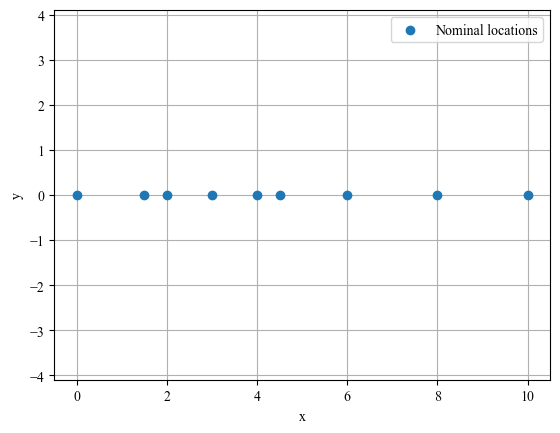

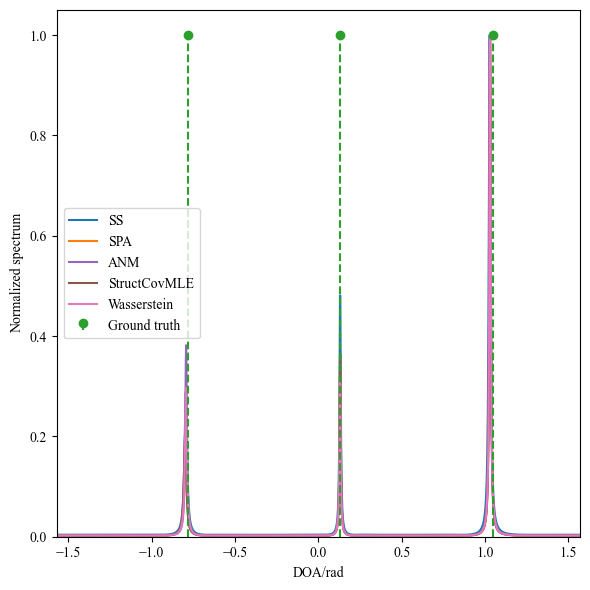

In [5]:
# Plot the results.
plot_array(cpa)

fig,ax = plt.subplots(1, 1, figsize=(6, 6))
doaplt.plot_spectrum(
    {   'SS': sp_ss,
        'SPA': sp_spa,
        'ANM': sp_anm,
        'StructCovMLE': sp_struct,
        'Wasserstein': sp_wasserstein
     },
    grid=grid,
    ax=ax,
    ground_truth=sources
)

plt.tight_layout()
plt.show()

## Performance Comparison

In [6]:
# Calculate and print the root mean square error (RMSE) for each method
methods = ['SS', 'SPA', 'ANM', 'StructCovMLE', 'Wasserstein']
estimations = [est_ss, est_spa, est_anm, est_struct, est_wasserstein]

for method, est in zip(methods, estimations):
    if est is not None:
        # Sort the estimates and ground truth for RMSE calculation
        sorted_est = np.sort(est.locations)
        sorted_gt = np.sort(sources.locations)
        rmse = np.sqrt(np.mean((sorted_est - sorted_gt) ** 2))
        print(f'{method}: RMSE = {rmse} radians')
    else:
        print(f'{method}: Failed to estimate sources')

# Calculate and print the resolution success rate
for method, est in zip(methods, estimations):
    if est is not None:
        # Check if all sources are correctly estimated
        success = len(est) == sources.size
        print(f'{method}: Resolution success = {success}')
    else:
        print(f'{method}: Resolution success = False')

SS: RMSE = 0.012626022718511817 radians
SPA: RMSE = 0.01294370815812412 radians
ANM: RMSE = 0.012217304763960256 radians
StructCovMLE: RMSE = 0.01355676374623802 radians
Wasserstein: RMSE = 0.011794431809230873 radians
SS: Resolution success = True
SPA: Resolution success = True
ANM: Resolution success = True
StructCovMLE: Resolution success = True
Wasserstein: Resolution success = True


## NRLA非冗余稀疏阵列
**NRLA** is

In [7]:
nrla = model.GridBasedArrayDesign(indices=np.array([0, 1, 4, 9, 20, 22])[:, np.newaxis], d0=d0, name='ONRA-da')
# However, we have 10 sources here.
sources = model.FarField1DSourcePlacement(
    np.linspace(-np.pi/3, np.pi/3, 10)
)
# Generate snapshots according to the stochastic model.
source_signal = model.ComplexStochasticSignal(sources.size, power_source)
noise_signal = model.ComplexStochasticSignal(nrla.size, power_noise)
y_nrla, R_nrla = model.get_narrowband_snapshots(
    nrla, sources, wavelength, source_signal, noise_signal,
    n_snapshots, return_covariance=True
) 

# Test all four algorithms on the nested array
algorithms = [
    estimation.SPAEstimator(nrla, wavelength),
    estimation.ANMEstimator(nrla, wavelength),
    estimation.StructCovMLEEstimator(nrla, wavelength),
    estimation.WassersteinEstimator(nrla, wavelength)
]

algo_names = ['SPA', 'ANM', 'StructCovMLE', 'Wasserstein']
estimates_nla = []
spectrums_nla = []

for algo in algorithms:
    resv, est, sp = algo.estimate(R_nrla, sources.size, return_spectrum=True, search_grid=grid)
    estimates_nla.append(est)
    spectrums_nla.append(sp)

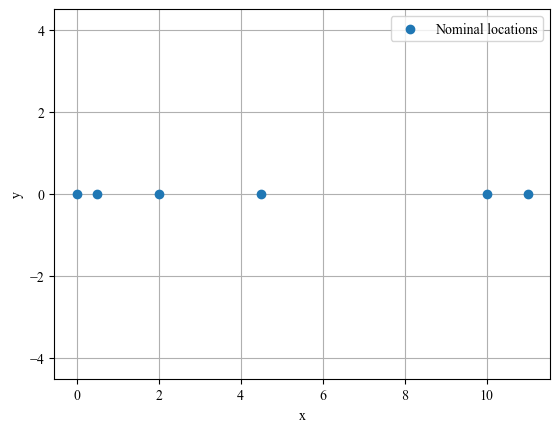

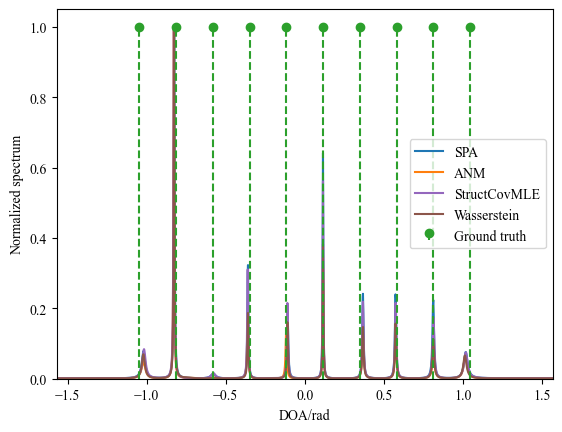

(<Axes: xlabel='DOA/rad', ylabel='Normalized spectrum'>,
 [[<matplotlib.lines.Line2D at 0x18c37a0dbe0>],
  <StemContainer object of 3 artists>])

In [8]:
# Plot the results for Nested array
plot_array(nrla)

doaplt.plot_spectrum(
    {
        'SPA': spectrums_nla[0],
        'ANM': spectrums_nla[1],
        'StructCovMLE': spectrums_nla[2],
        'Wasserstein': spectrums_nla[3]
     },
    grid=grid,
    ground_truth=sources
)


## Nested Array Performance

In [9]:
# Calculate and print the RMSE for each method on nested array
for method, est in zip(algo_names, estimates_nla):
    if est is not None:
        sorted_est = np.sort(est.locations)
        sorted_gt = np.sort(sources.locations)
        rmse = np.sqrt(np.mean((sorted_est - sorted_gt) ** 2))
        print(f'{method} on Nested Array: RMSE = {rmse:.6f} radians')
    else:
        print(f'{method} on Nested Array: Failed to estimate sources')

SPA on Nested Array: RMSE = 0.014870 radians
ANM on Nested Array: RMSE = 0.015937 radians
StructCovMLE on Nested Array: RMSE = 0.015718 radians
Wasserstein on Nested Array: RMSE = 0.015975 radians
